In [1]:
import os
import pandas as pd
import seaborn as sns
import numpy as np
from hlsstack.hls_funcs.smooth import despike_ts, double_savgol
from datetime import datetime, timedelta

In [2]:
df_ndvi = pd.read_csv('EC_Tower_Locations19_24_hls NDVI.csv', parse_dates=['Date'])
df_ndvi = df_ndvi[['EC_Tower', 'Date', 'NDVI', 'NDVI_smooth']].rename(columns={'NDVI_smooth': 'Old_smooth'})
df_ndvi['Year'] = df_ndvi['Date'].dt.year
df_ndvi['DOY'] = df_ndvi['Date'].dt.dayofyear
df_ndvi = df_ndvi[df_ndvi['Year'] > 2016]

In [3]:
df_template = pd.DataFrame(columns=['Date'])
for g, dat in df_ndvi.groupby(['Year', 'EC_Tower']):
    df_template = pd.concat([df_template, pd.DataFrame({
        'Date': pd.date_range(datetime(g[0], 1, 1), datetime(g[0], 12, 31)),
        'EC_Tower': g[1]})])
df_template['Date'] = pd.to_datetime(df_template['Date'])

In [4]:
df_ndvi = pd.merge(df_template, df_ndvi, on=['Date', 'EC_Tower'], how='left')
df_ndvi['Year'] = df_ndvi['Date'].dt.year
df_ndvi['DOY'] = df_ndvi['Date'].dt.dayofyear

In [5]:
def fine_smooth_ndvi(ts):
    ts_ds = pd.Series(
        despike_ts(ts.values, dat_thresh=0.05, days_thresh=31)).interpolate(limit=None)
    ts_smooth = pd.Series(double_savgol(ts_ds.values, double=False, window2=21), index=ts.index)
    return ts_smooth

def full_smooth_ndvi(ts):
    ts_ds = pd.Series(
        despike_ts(ts.values, dat_thresh=0.025, days_thresh=61)).interpolate(limit=None)
    ts_smooth = pd.Series(double_savgol(ts_ds.values, window2=91), index=ts.index)
    return ts_smooth

def running_mean(x, N):
    cumsum = np.cumsum(np.insert(x, 0, 0))
    return (cumsum[N:] - cumsum[:-N]) / float(N)
    
def calc_sos(ndvi_ts):
    ndvi_thresh1 = np.nanpercentile(ndvi_ts[91:201], 40.0)
    date_thresh1 = next(x for x in np.where(ndvi_ts > ndvi_thresh1)[0] if x > 30)
    dndvi_ts = np.ones_like(ndvi_ts) * np.nan
    dndvi_ts[25:] = running_mean(np.diff(ndvi_ts), 25)
    dndvi_thresh2 = np.nanpercentile(dndvi_ts[:date_thresh1], 35.0)
    try:
        sos = np.where(dndvi_ts[:date_thresh1] < dndvi_thresh2)[0][-1]
    except IndexError:
        sos = np.nan
    return sos

def weighted_ndvi(ndvi_smooth1, ndvi_smooth2, sos):
    weights1 = np.ones_like(ndvi_smooth1)
    peak = np.argmax(ndvi_smooth1[120:300]) + 120
    weights1[:sos] = 0
    weights1[sos:peak] = np.linspace(0, 1, peak-sos)**4
    weights1[peak:] = np.linspace(1, 0, len(ndvi_smooth1) - peak)**4
    weights2 = 1.0 - weights1
    ndvi_wtd = np.average(np.array([ndvi_smooth1, ndvi_smooth2]), axis=0, weights=np.array([weights1, weights2]))
    return pd.Series(ndvi_wtd, index=ndvi_smooth1.index)

In [6]:
# run initial NDVI smoothing
vals_smooth_yr = df_ndvi.groupby(['EC_Tower', 'Year']).apply(lambda x: fine_smooth_ndvi(x['NDVI']))
df_ndvi['NDVI_smooth'] = vals_smooth_yr.droplevel(list(np.arange(vals_smooth_yr.index.nlevels-1)))
# run secondary NDVI smoothing on full time series
ndvi_ts_smooth = df_ndvi.groupby(['EC_Tower', 'Year']).apply(lambda x: full_smooth_ndvi(x['NDVI']))
df_ndvi['NDVI_smooth2'] = ndvi_ts_smooth.droplevel(list(np.arange(ndvi_ts_smooth.index.nlevels-1)))
# calculate start of season as DOY for each plot and year
df_sos = df_ndvi.groupby(['EC_Tower', 'Year'])['NDVI_smooth2'].apply(
    lambda x: calc_sos(x)).reset_index().rename(columns={'NDVI_smooth2': 'SOS_doy'})
# get as date
df_sos['SOS_date'] = df_sos.apply(lambda x: datetime(x['Year'], 1, 1) + timedelta(days=x['SOS_doy']), axis=1)
# get average from two smooths, weighted by distance to SOS and peak NDVI 
ndvi_smooth_avg = df_ndvi.groupby(['EC_Tower', 'Year']).apply(lambda x: weighted_ndvi(x['NDVI_smooth'], 
                                                                                     x['NDVI_smooth2'],
                                                                                     df_sos[(df_sos['EC_Tower'] == x.name[0]) &
                                                                                           (df_sos['Year'] == x.name[1])]['SOS_doy'].values[0]))
df_ndvi['NDVI_smooth_avg'] = ndvi_smooth_avg.droplevel(list(np.arange(ndvi_smooth_avg.index.nlevels-1)))

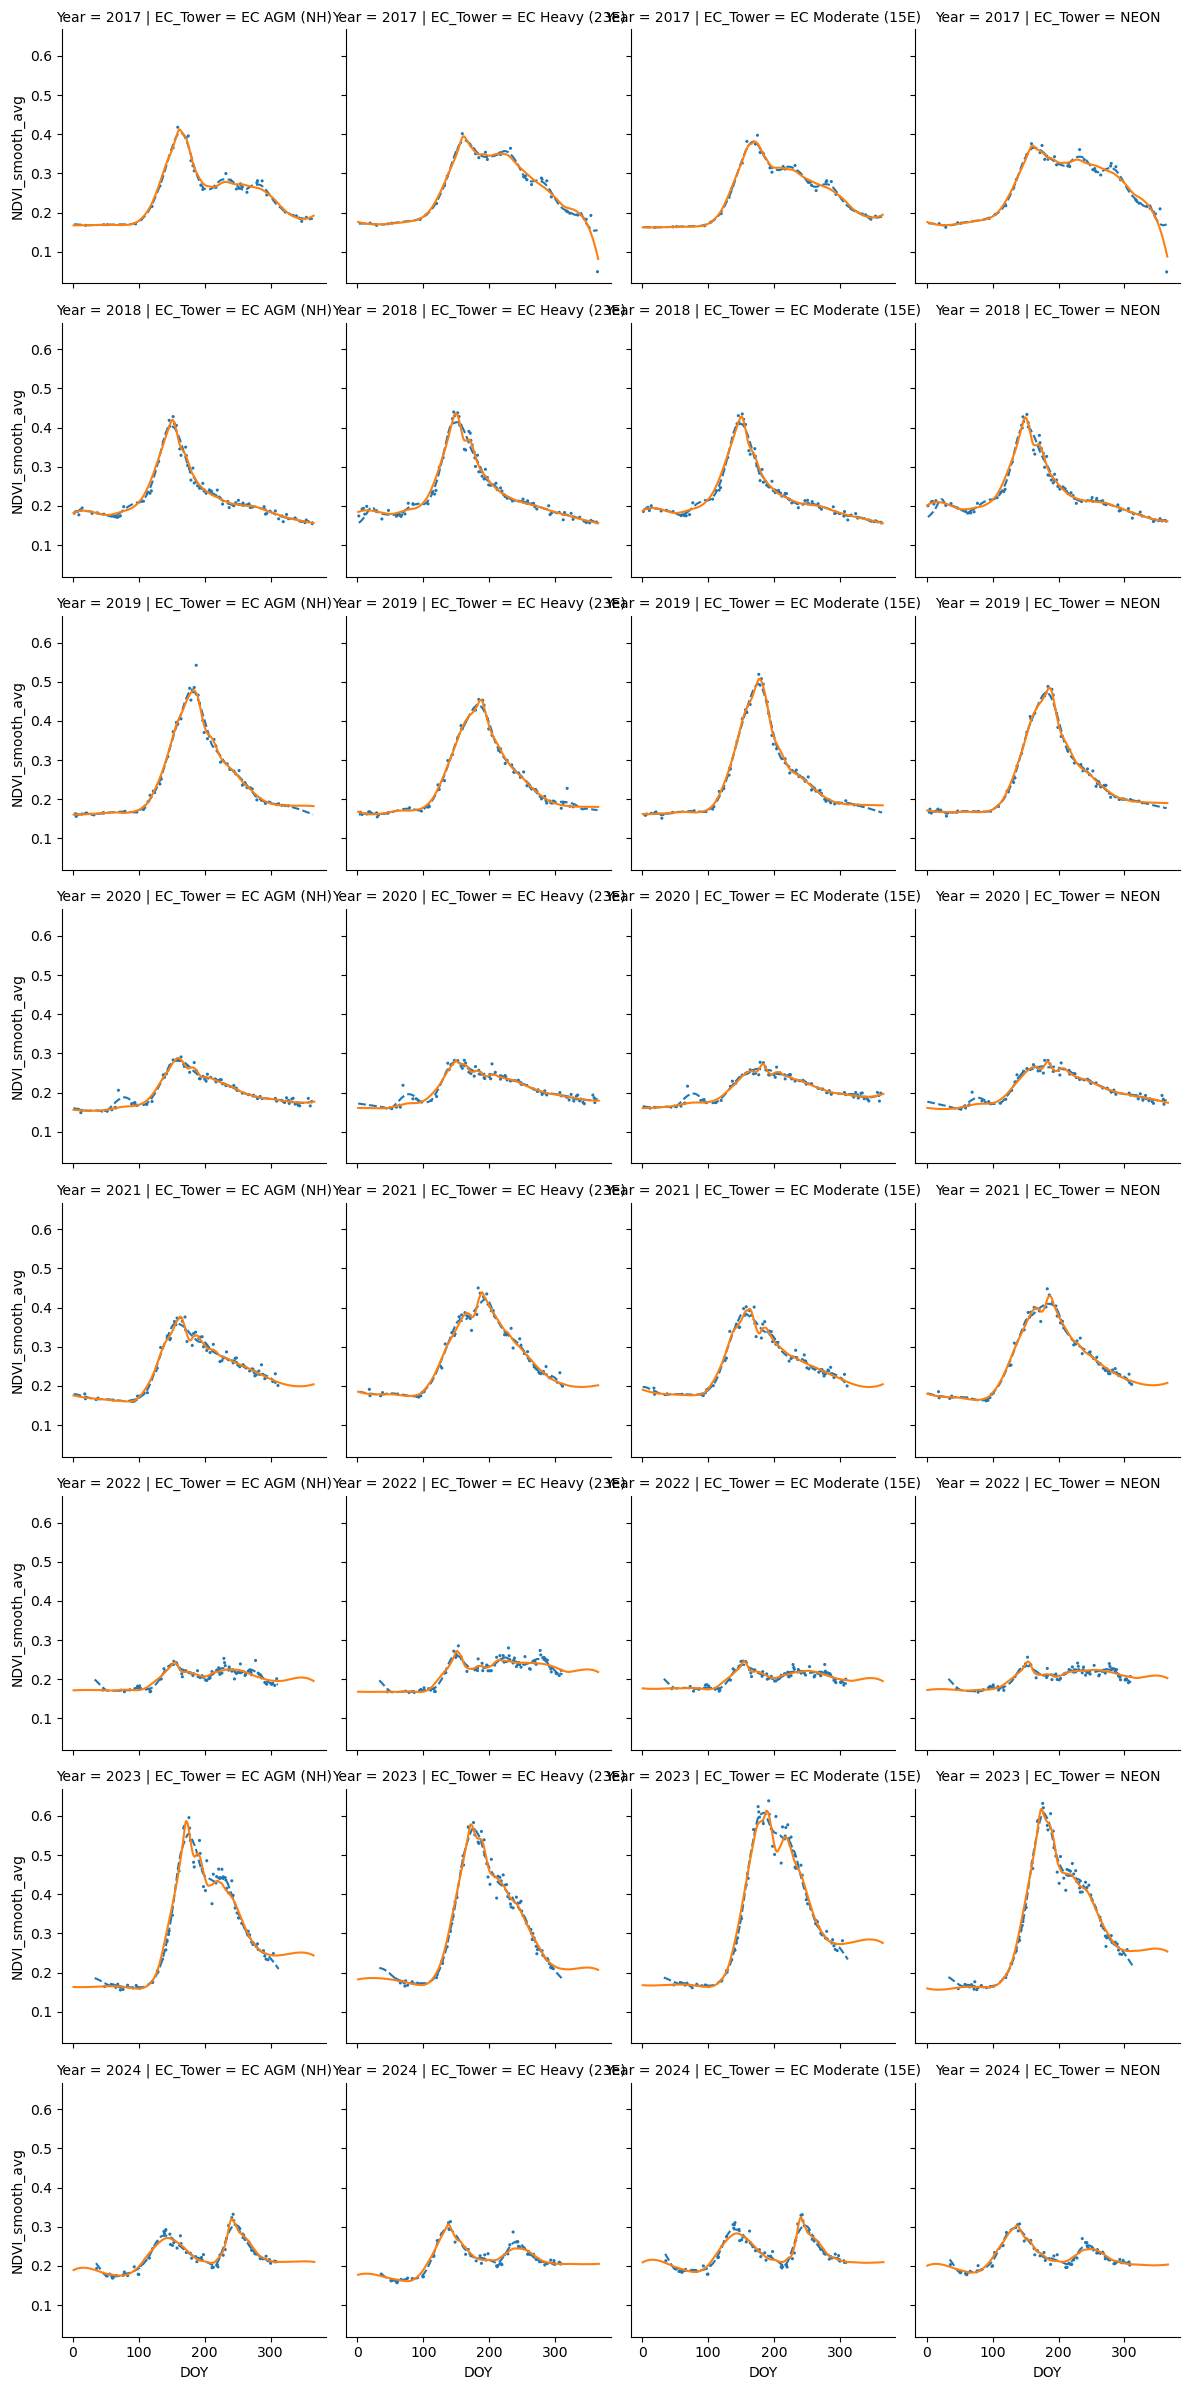

In [7]:
g = sns.FacetGrid(data=df_ndvi, col='EC_Tower', row='Year')
g.map_dataframe(sns.scatterplot, x='DOY', y='NDVI', ec=None, s=5)
g.map_dataframe(sns.lineplot, x='DOY', y='Old_smooth', color='tab:blue', linestyle='dashed')
g.map_dataframe(sns.lineplot, x='DOY', y='NDVI_smooth_avg', color='tab:orange')

In [8]:
#df_sos

In [9]:
peak_vals = df_ndvi.groupby(['EC_Tower', 'Year']).apply(lambda x: datetime(x.name[1], 1, 1) + timedelta(days=int(x['NDVI_smooth_avg'].argmax()-1)))
df_sos['Peak'] = peak_vals.droplevel(list(np.arange(peak_vals.index.nlevels-1))).values

In [10]:
df_sos['Peak_doy'] = df_sos['Peak'].dt.dayofyear

In [11]:
def pheno_fq_metrics(ndvi_ts_mean):


    """
    ndvi_ts_mean (1-d array): time series of NDVI values for an entire calendar year (e.g., mean for a single pasture)
    produce_ts (boolean): whether to return the entire time series (default) or just average between b_start and b_end (see below)
    b_start (int): the day of year for the start of the time series subset to average over for output. Only used if produce_ts==False.
    b_end (int): the day of the year for the end of the time series subset to average over for output. Only used if produce_ts==False.
    """

    def running_mean(x, N):
        cumsum = np.nancumsum(np.insert(x, 0, 0))
        return (cumsum[N:] - cumsum[:-N]) / float(N)

    def ndvi_int_calc(ts, base, sos):
        ts_tmp = ts - base
        ndvi_int_ts = np.ones_like(ts_tmp) * np.nan
        for b_i in range(ts_tmp.shape[0]):
            ndvi_int_ts[b_i] = np.nansum(ts_tmp[sos:b_i + 1])
        return ndvi_int_ts

    # get length of time series
    b = len(ndvi_ts_mean)
    
    if (sum(np.isnan(ndvi_ts_mean)) < b*0.5) and (sum(~np.isnan(ndvi_ts_mean[10:75])) > 0):
        try:
            # calculate start of season and base ndvi
            ndvi_thresh1 = np.nanpercentile(ndvi_ts_mean[91:201], 40.0)
            date_thresh1 = next(x for x in np.where(ndvi_ts_mean > ndvi_thresh1)[0] if x > 30)
            dndvi_ts_mean = np.ones_like(ndvi_ts_mean) * np.nan
            dndvi_ts_mean[25:] = running_mean(np.diff(ndvi_ts_mean), 25)
            dndvi_thresh2 = np.nanpercentile(dndvi_ts_mean[:date_thresh1][dndvi_ts_mean[:date_thresh1] > 0], 35.0)
            sos = np.where(dndvi_ts_mean[:date_thresh1] < dndvi_thresh2)[0][-1]
            ndvi_base = np.nanmean(ndvi_ts_mean[10:75])
        
            # calculate 'instantaneous greenup rate (IGR)' with potentially different lags
            ndvi_ts_smooth_d1 = np.diff(ndvi_ts_mean, prepend=ndvi_ts_mean[0])
        
            ndvi_ts_smooth_d1_cum30 = np.empty_like(ndvi_ts_smooth_d1)
            for i in range(b):
                ndvi_ts_smooth_d1_cum30[i] = np.nansum(ndvi_ts_smooth_d1[i - 30:i], axis=0)
        
            # cleanup and reshape IGR metrics
            ndvi_ts_smooth_d1_cum30[np.where(np.isnan(ndvi_ts_smooth_d1))] = np.nan
        
            # calculate integrated ndvi
            ndvi_int_ts = ndvi_int_calc(ndvi_ts_mean, ndvi_base, sos)
            ndvi_rate_ts = np.zeros_like(ndvi_int_ts)
        
            # calculate rate of change
            ndvi_rate_ts[sos:] = ndvi_int_ts[sos:] / (range(sos, ndvi_int_ts.shape[0]) - sos + 1)
        
            # calculate percent dry biomass estimate
            ndvi_dry_ts = np.zeros_like(ndvi_int_ts)
            ndvi_int_dry_ts = np.zeros_like(ndvi_int_ts)
            for i in range(sos, ndvi_dry_ts.shape[0]):
                if ndvi_ts_smooth_d1[i] < 0:
                    ndvi_dry_ts[i] = (-1.0 * ndvi_ts_smooth_d1[i] / np.nanmax(ndvi_ts_mean[:i])) * ndvi_int_ts[i]
                ndvi_int_dry_ts[i] = np.nansum(ndvi_dry_ts[:i])
        
            ndvi_int_dry_pct_ts = np.zeros_like(ndvi_int_ts)
            ndvi_int_dry_pct_ts[ndvi_int_ts != 0] = ndvi_int_dry_ts[ndvi_int_ts != 0] / ndvi_int_ts[ndvi_int_ts != 0]
            
            # create the output dataframe
            df_out = pd.DataFrame(
                {
                    'NDVI': ndvi_ts_mean,
                    'NDVI_d30': ndvi_ts_smooth_d1_cum30,
                    'iNDVI':ndvi_int_ts,
                    'iNDVI_dry': ndvi_int_dry_ts,
                    'NDVI_rate': ndvi_rate_ts,
                    'iNDVI_dry_pct': ndvi_int_dry_pct_ts,
                    'SOS_doy': sos,
                    't_SOS': np.arange(b) - sos
                }
            )
            return df_out
        # return all NaN values if an IndexError occurs - this is usually due to inability to get thresholds
        #except IndexError:
        except Exception as e: 
            #print(e)
            return np.ones_like(ndvi_ts_mean) * np.nan
    else:
        return np.ones_like(ndvi_ts_mean) * np.nan

In [12]:
pheno_metrics = df_ndvi.groupby(['EC_Tower', 'Year']).apply(lambda x: pheno_fq_metrics(x['NDVI_smooth_avg'].values))
df_sos['SOS_doy'] = pheno_metrics.reset_index().groupby(['EC_Tower', 'Year']).first()['SOS_doy'].values
df_sos['SOS_date'] = df_sos.apply(lambda x: datetime(x['Year'], 1, 1) + timedelta(days=x['SOS_doy'] - 1), axis=1)

In [13]:
df_sos.to_csv('ec_tower_ndvi_sos_peak.csv', index=False)

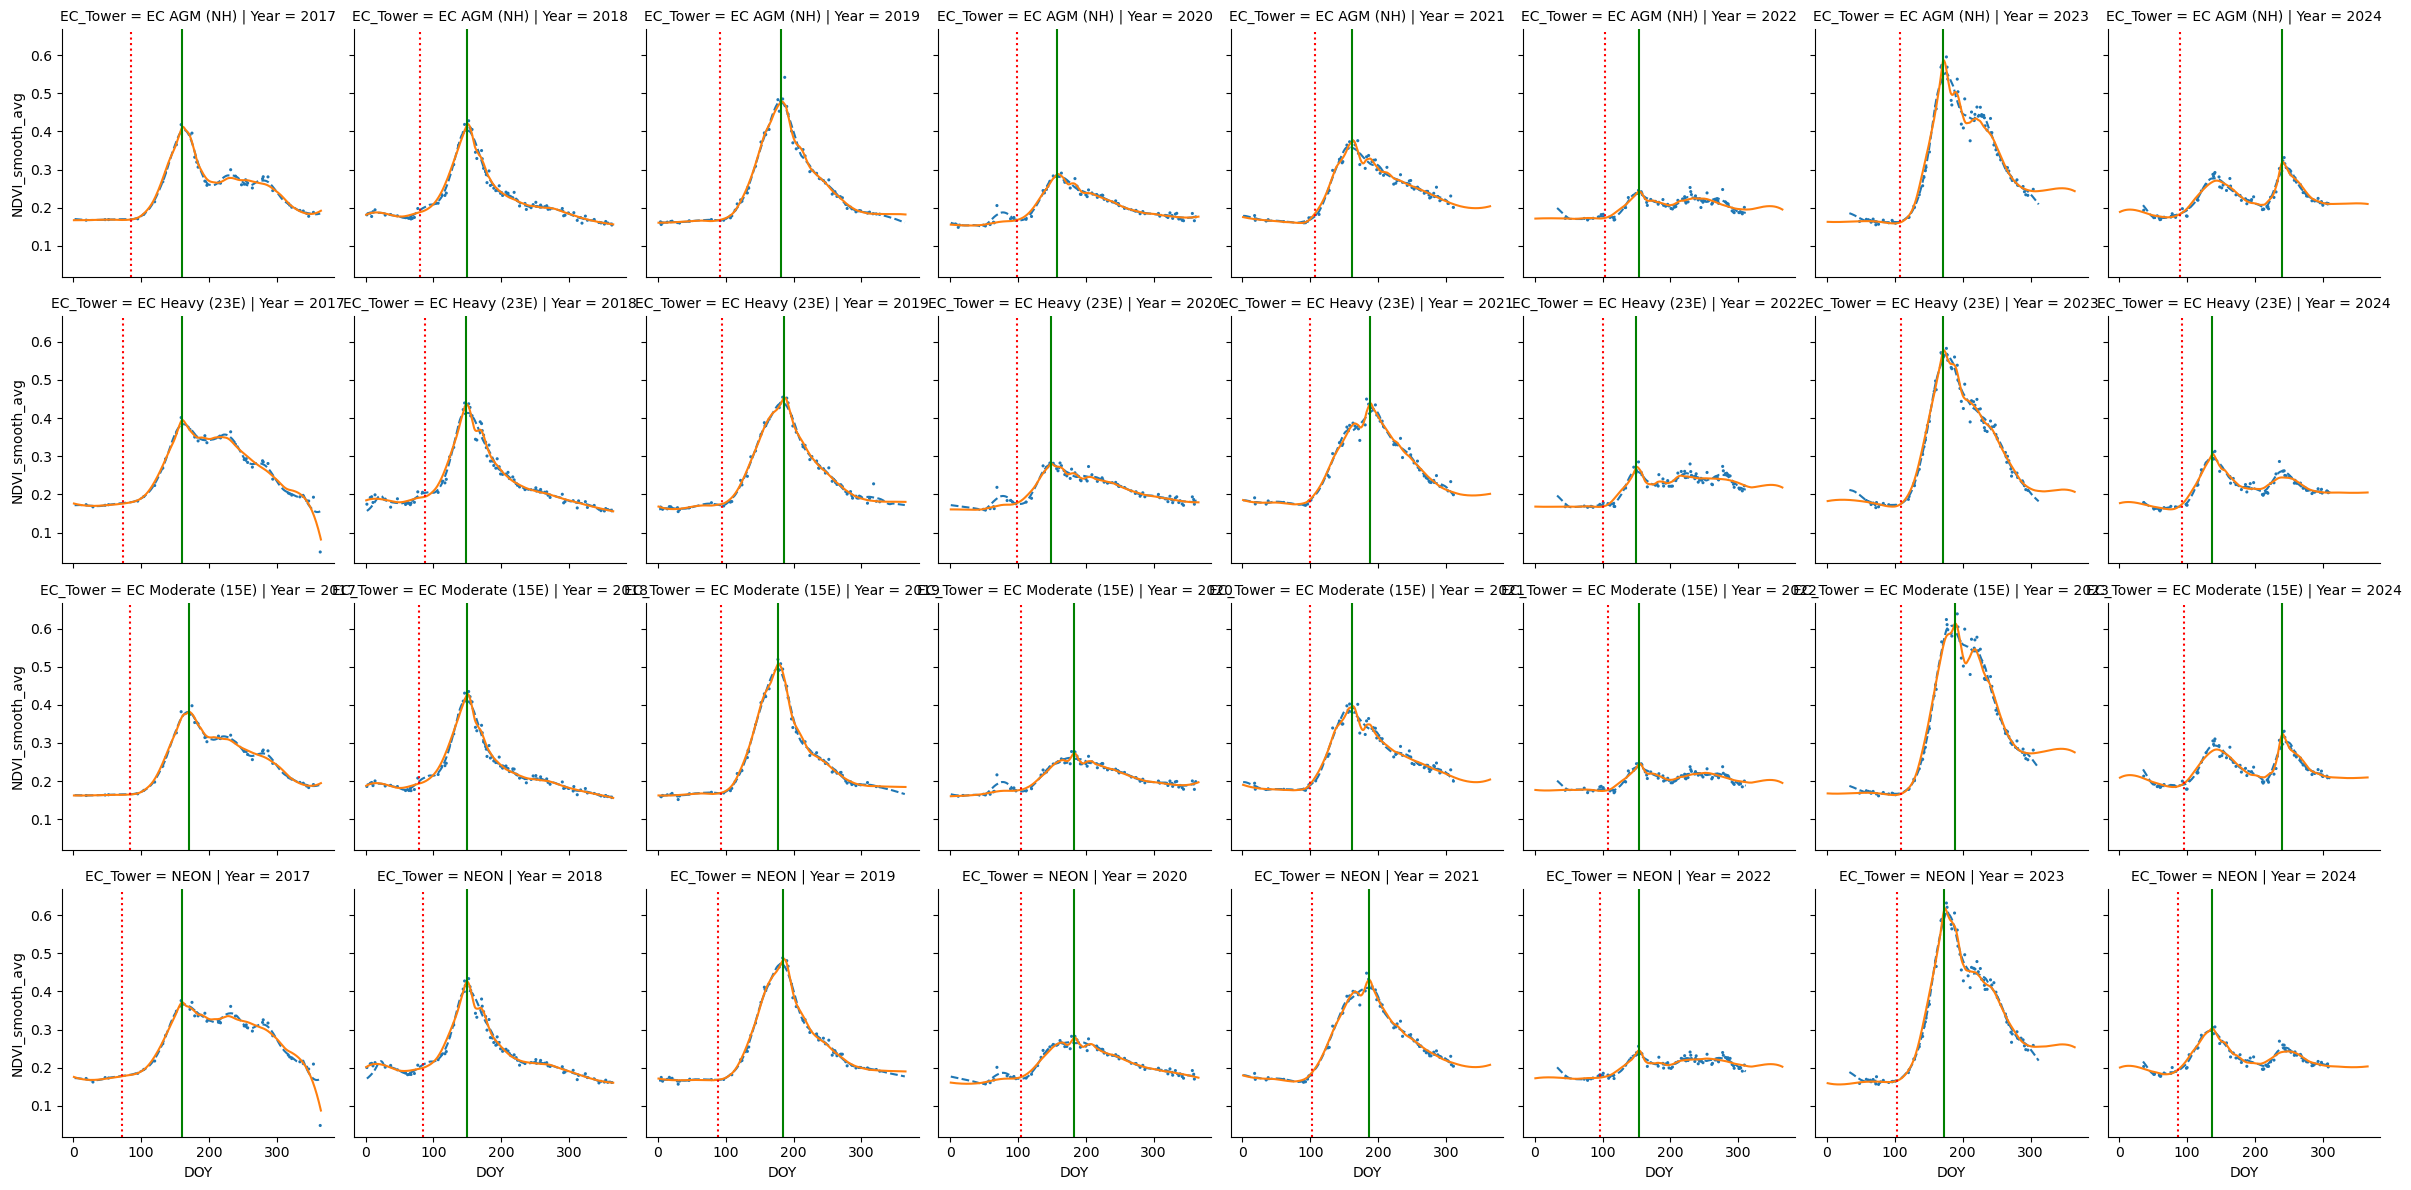

In [15]:
g = sns.FacetGrid(data=df_ndvi, row='EC_Tower', col='Year')
g.map_dataframe(sns.scatterplot, x='DOY', y='NDVI', ec=None, s=5)
g.map_dataframe(sns.lineplot, x='DOY', y='Old_smooth', color='tab:blue', linestyle='dashed')
g.map_dataframe(sns.lineplot, x='DOY', y='NDVI_smooth_avg', color='tab:orange')
for idx, ax in enumerate(g.axes.flatten()):
    ax.axvline(x=df_sos['SOS_doy'].iloc[idx], color='red', linestyle='dotted')
    ax.axvline(x=df_sos['Peak_doy'].iloc[idx], color='green')

In [16]:
from scipy.optimize import curve_fit

def double_logistic(x, vmin, vmax, sos, scaleS, eos, scaleA):
    y = vmin + vmax * ((1 / (1 + np.exp(-scaleS * (x - sos)))) + (1 / (1 + np.exp(scaleA * (x - eos)))) - 1)
    return y

In [17]:
def apply_dl(dat_ts, maxiter=10000, tol=0.00001):
    ndvi_smooth = pd.Series(dat_ts)
    if ndvi_smooth.isnull().all():
        return ndvi_smooth
    else:
        try:
            p0 = [ndvi_smooth.quantile(q=0.01),
                  np.max(ndvi_smooth),
                  int(np.percentile(ndvi_smooth.index, 25)),
                  1.0,
                  int(np.percentile(ndvi_smooth.index, 75)),
                  1.0]  # this is a mandatory initial guess
            popt, pcov = curve_fit(double_logistic, ndvi_smooth.index, ndvi_smooth,
                                   p0, method='lm', maxfev=20000, ftol=tol, xtol=tol)
            ndvi_dl = double_logistic(ndvi_smooth.index, *popt)
        except RuntimeError:
            try:
                p0 = [ndvi_smooth.quantile(q=0.01),
                      np.max(ndvi_smooth),
                      120,
                      1.0,
                      265,
                      1.0]  # this is a mandatory initial guess
                popt, pcov = curve_fit(double_logistic, ndvi_smooth.index, ndvi_smooth,
                                       p0, method='lm', maxfev=maxiter, ftol=tol, xtol=tol)
                ndvi_dl = double_logistic(ndvi_smooth.index, *popt)
            except RuntimeError:
                ndvi_dl = ndvi_smooth * np.nan
                print(RuntimeError)
        return ndvi_dl

In [18]:
df_ndvi['NDVI_dl'] = df_ndvi.groupby(['EC_Tower', 'Year'])['NDVI_smooth_avg'].transform(lambda x: apply_dl(x))
#df_ndvi['NDVI_dl'] = dl_vals.droplevel(list(np.arange(dl_vals.index.nlevels-1)))

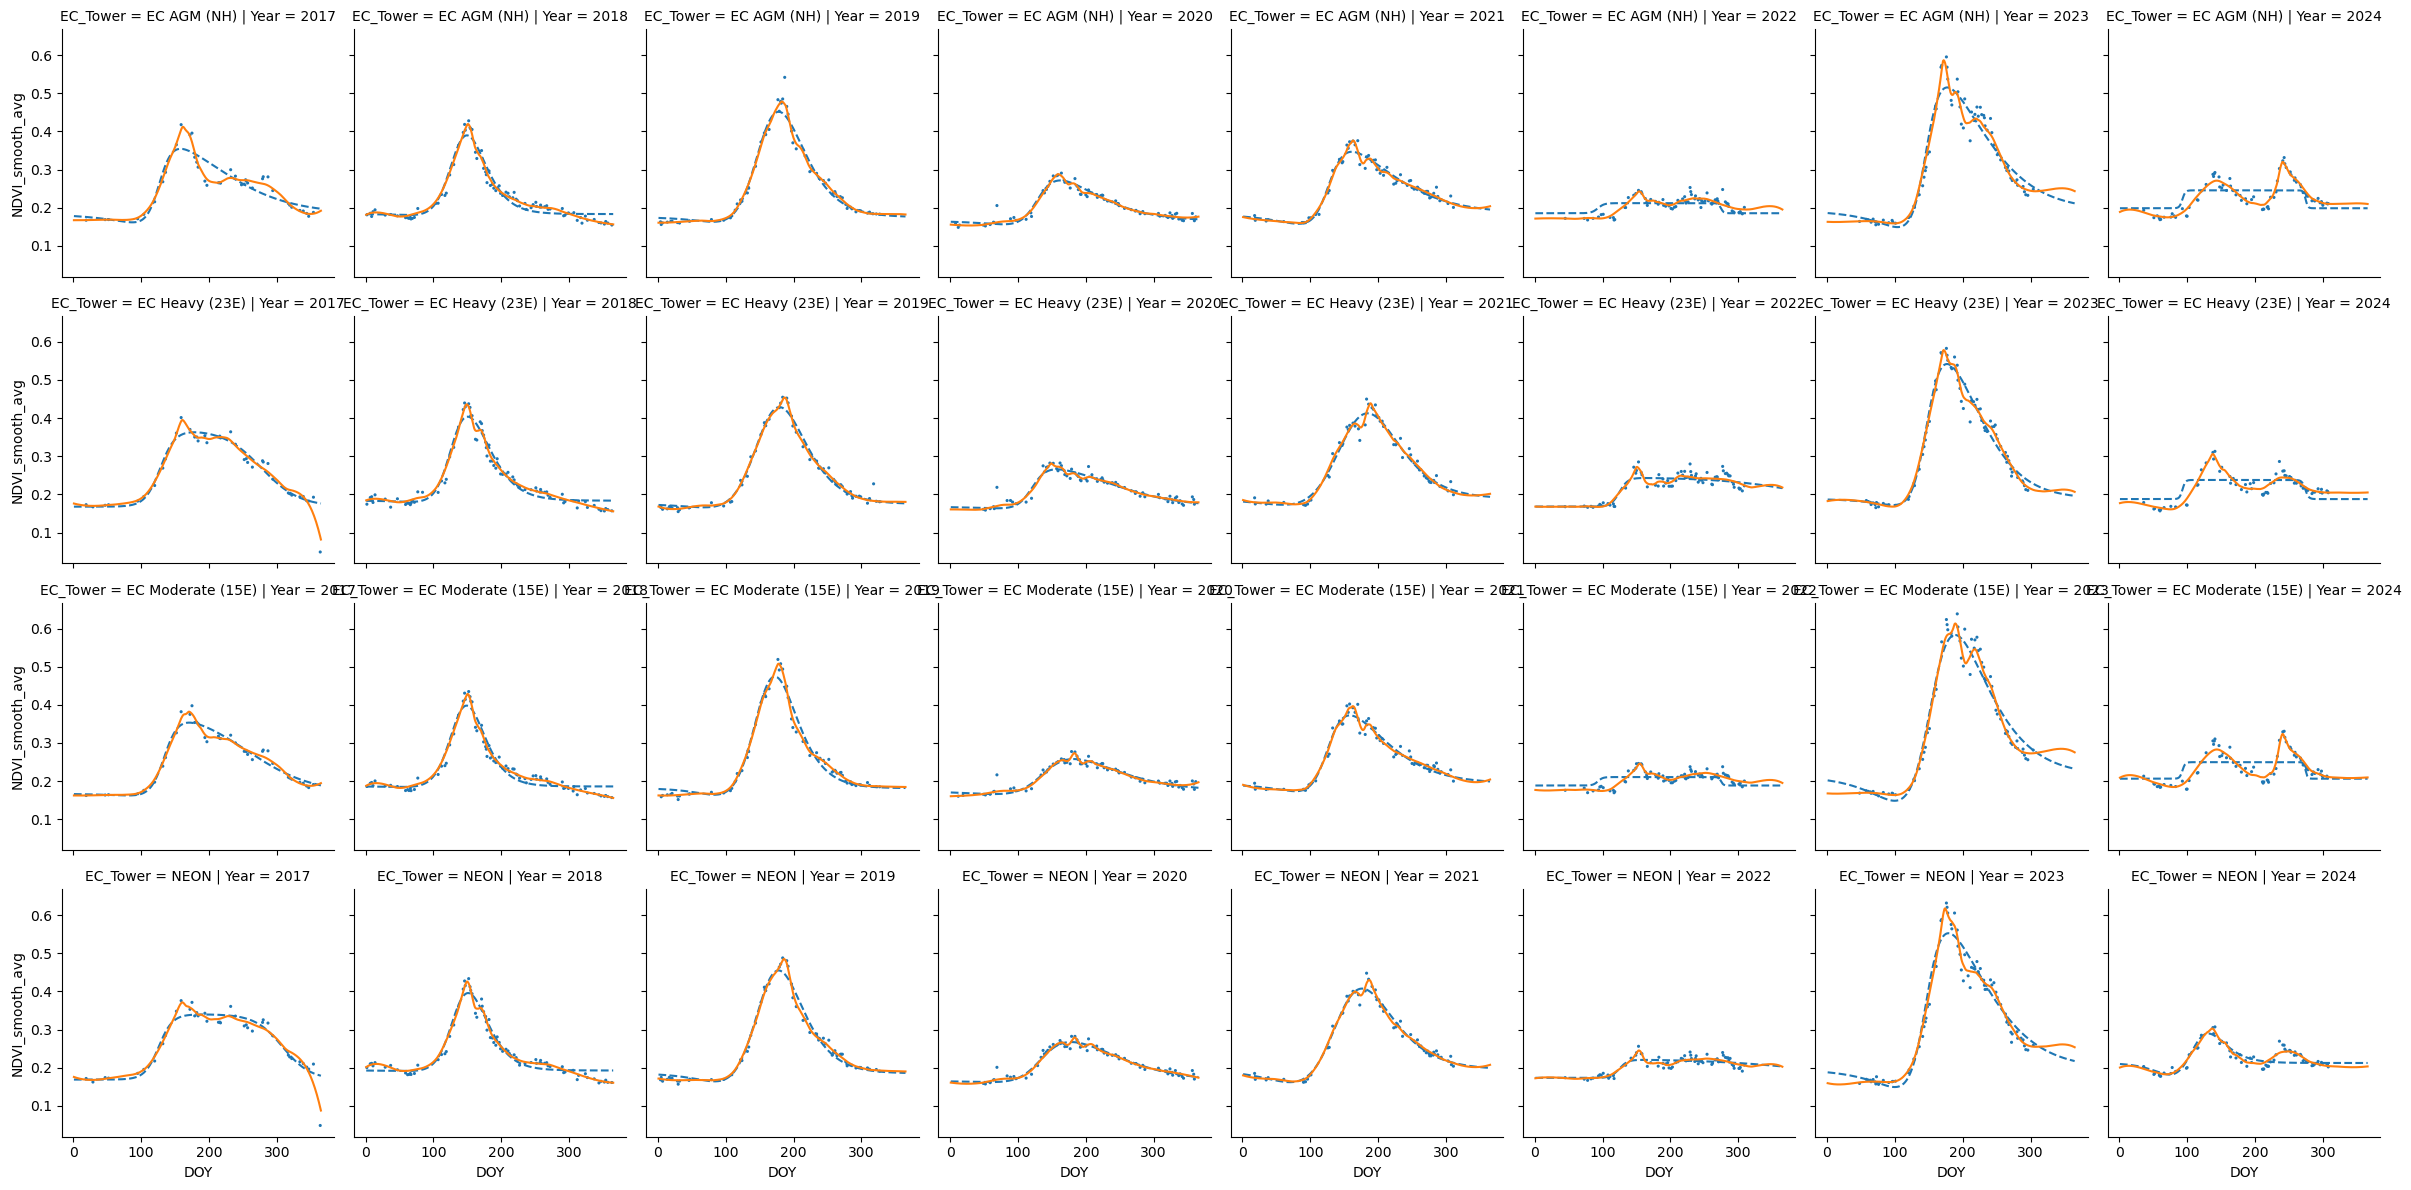

In [28]:
g = sns.FacetGrid(data=df_ndvi, row='EC_Tower', col='Year')
g.map_dataframe(sns.scatterplot, x='DOY', y='NDVI', ec=None, s=5)
g.map_dataframe(sns.lineplot, x='DOY', y='NDVI_dl', color='tab:blue', linestyle='dashed')
g.map_dataframe(sns.lineplot, x='DOY', y='NDVI_smooth_avg', color='tab:orange')

In [26]:
from scipy.signal import find_peaks

def pheno_phases(df_ndvi_ts, smooth_col, dl_col):
    df_ndvi_ts = df_ndvi_ts.reset_index()
    try:
        day_ndvi_pk = df_ndvi_ts[smooth_col][90:305].idxmax()
        ndvi_pk = df_ndvi_ts[smooth_col][90:305].max()
        ndvi_base_gu = df_ndvi_ts.loc[:day_ndvi_pk, dl_col].quantile(q=0.025)
        ndvi_base_gd = df_ndvi_ts.loc[day_ndvi_pk:, dl_col].quantile(q=0.025)
        ndvi_amp_max_gu = ndvi_pk - ndvi_base_gu
        ndvi_amp_max_gd = ndvi_pk - ndvi_base_gd
        ndvi_amp_gu = df_ndvi_ts[smooth_col].loc[:day_ndvi_pk] - ndvi_base_gu
        doys_arr = pd.Series(np.ones_like(df_ndvi_ts[smooth_col]) * (df_ndvi_ts.index + 1))
        doys_arr_gu = doys_arr.loc[:day_ndvi_pk]
        sos = doys_arr_gu.loc[(ndvi_amp_gu.shift(1) < (0.15 * ndvi_amp_max_gu)) &
                           (ndvi_amp_gu > (0.15 * ndvi_amp_max_gu))].idxmax() + 1
        mgu = doys_arr_gu.loc[(ndvi_amp_gu.shift(1) < (0.50 * ndvi_amp_max_gu)) &
                              (ndvi_amp_gu > (0.50 * ndvi_amp_max_gu))].idxmax() + 1
        mat = doys_arr_gu.loc[(ndvi_amp_gu.shift(1) < (0.90 * ndvi_amp_max_gu)) &
                              (ndvi_amp_gu > (0.90 * ndvi_amp_max_gu))].idxmax() + 1
        pos = df_ndvi_ts[smooth_col].idxmax() + 1
        ndvi_amp_gd = df_ndvi_ts[smooth_col].loc[day_ndvi_pk:, ] - ndvi_base_gd
        doys_arr_gd = doys_arr.loc[day_ndvi_pk:]
        sen = doys_arr_gd.loc[(ndvi_amp_gd.shift(1) > (0.90 * ndvi_amp_max_gd)) &
                              (ndvi_amp_gd < (0.90 * ndvi_amp_max_gd))].idxmax() + 1
        mgd = doys_arr_gd.loc[(ndvi_amp_gd.shift(1) > (0.50 * ndvi_amp_max_gd)) &
                              (ndvi_amp_gd < (0.50 * ndvi_amp_max_gd))].idxmax() + 1
        eos = doys_arr_gd.loc[(ndvi_amp_gd.shift(1) > (0.15 * ndvi_amp_max_gd)) &
                              (ndvi_amp_gd < (0.15 * ndvi_amp_max_gd))].idxmax() + 1
        ndvi_gs_mean = df_ndvi_ts[smooth_col][sos:eos].mean()
        pks = find_peaks(df_ndvi_ts[smooth_col], prominence=0.05, distance=10, width=10, height=ndvi_pk*0.5)[0]
        pks = [x for x in pks if (x > mgu) & (x < mgd)]
        num_pks = len(pks)
        if num_pks > 1:
            pos2 = pks[-1]
        else:
            pos2 = np.nan
        return pd.Series(dict(
            ndvi_max=ndvi_pk,
            ndvi_gs_mean=ndvi_gs_mean,
            SOS=sos,
            MGU=mgu,
            MAT=mat,
            POS=pos,
            POS2=pos2,
            SEN=sen,
            MGD=mgd,
            EOS=eos,
            LGU=mat-sos,
            LGS=mgd-mgu,
            LGD=eos-sen,
            LOS=eos-sos,
            num_pks=num_pks))
    except ValueError:
        return pd.Series(dict(
            ndvi_max=np.nan,
            ndvi_gs_mean=np.nan,
            SOS=np.nan,
            MGU=np.nan,
            MAT=np.nan,
            POS=np.nan,
            POS2=np.nan,
            SEN=np.nan,
            MGD=np.nan,
            EOS=np.nan,
            LGU=np.nan,
            LGS=np.nan,
            LGD=np.nan,
            LOS=np.nan,
            num_pks=np.nan))

In [27]:
df_ndvi.groupby(['EC_Tower', 'Year']).apply(lambda x: pheno_phases(x, 'NDVI_smooth_avg', 'NDVI_dl'))

ndvi_max  ndvi_gs_mean    SOS    MGU    MAT    POS  \
EC_Tower          Year                                                       
EC AGM (NH)       2017  0.412245      0.288912  112.0  134.0  156.0  162.0   
                  2018  0.419576      0.296874  104.0  126.0  145.0  151.0   
                  2019  0.478605      0.334589  121.0  146.0  172.0  183.0   
                  2020  0.288201      0.230351  110.0  132.0  152.0  159.0   
                  2021  0.376331      0.283201  110.0  130.0  155.0  163.0   
                  2022       NaN           NaN    NaN    NaN    NaN    NaN   
                  2023  0.586951      0.405179  131.0  151.0  168.0  172.0   
                  2024  0.320563      0.260718  220.0  232.0  238.0  241.0   
EC Heavy (23E)    2017  0.395114      0.303303  108.0  134.0  155.0  161.0   
                  2018  0.436210      0.308541  105.0  126.0  144.0  149.0   
                  2019  0.454128      0.323695  117.0  143.0  177.0  187.0   
                  2020  0.281494      0.231141  103.0  126.0  144.0  149.0   
                  2021  0.438991      0.327512  112.0  137.0  183.0  189.0   
                  2022  0.271982      0.236527  115.0  133.0  148.0  151.0   
                  2023  0.578506      0.409174  129.0  148.0  167.0  172.0   
                  2024  0.305926      0.236572  106.0  120.0  134.0  138.0   
EC Moderate (15E) 2017  0.381859      0.294211  117.0  138.0  158.0  171.0   
                  2018  0.428124      0.303352  103.0  126.0  145.0  151.0   
                  2019  0.507678      0.342778  119.0  143.0  170.0  178.0   
                  2020  0.273177      0.227934  113.0  140.0  179.0  183.0   
                  2021  0.396543      0.297135  107.0  128.0  153.0  163.0   
                  2022  0.245646      0.210892  126.0  141.0  152.0  155.0   
                  2023  0.613256      0.450504  132.0  153.0  174.0  189.0   
                  2024  0.323799      0.267302  226.0  234.0  239.0  241.0   
NEON              2017  0.371297      0.300531  107.0  133.0  154.0  161.0   
                  2018  0.425876      0.311532  106.0  128.0  145.0  150.0   
                  2019  0.485329      0.337381  120.0  145.0  176.0  186.0   
                  2020  0.279178      0.231118  110.0  134.0  179.0  184.0   
                  2021  0.430057      0.318828  109.0  134.0  180.0  187.0   
                  2022  0.245096      0.216345  115.0  135.0  150.0  154.0   
                  2023  0.617893      0.423644  128.0  150.0  169.0  174.0   
                  2024  0.302601      0.241029   90.0  109.0  129.0  137.0   

                        POS2    SEN    MGD    EOS   LGU    LGS    LGD    LOS  \
EC_Tower          Year                                                         
EC AGM (NH)       2017   NaN  172.0  187.0  308.0  44.0   53.0  136.0  196.0   
                  2018   NaN  157.0  177.0  223.0  41.0   51.0   66.0  119.0   
                  2019   NaN  192.0  219.0  271.0  51.0   73.0   79.0  150.0   
                  2020   NaN  168.0  220.0  282.0  42.0   88.0  114.0  172.0   
                  2021   NaN  169.0  218.0  293.0  45.0   88.0  124.0  183.0   
                  2022   NaN    NaN    NaN    NaN   NaN    NaN    NaN    NaN   
                  2023   NaN  178.0  238.0  277.0  37.0   87.0   99.0  146.0   
                  2024   NaN  246.0  268.0  293.0  18.0   36.0   47.0   73.0   
EC Heavy (23E)    2017   NaN  170.0  266.0  323.0  47.0  132.0  153.0  215.0   
                  2018   NaN  156.0  183.0  231.0  39.0   57.0   75.0  126.0   
                  2019   NaN  194.0  221.0  272.0  60.0   78.0   78.0  155.0   
                  2020   NaN  163.0  240.0  306.0  41.0  114.0  143.0  203.0   
                  2021   NaN  197.0  237.0  284.0  71.0  100.0   87.0  172.0   
                  2022   NaN  155.0  233.0  306.0  33.0  100.0  151.0  191.0   
                  2023   NaN  188.0  234.0  279.0  38.0   86.0   91.0  150.0   
           